# Logistic Regression on Titanic Dataset

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix, roc_curve

In [47]:
df = pd.read_csv("Titanic_train.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [48]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [49]:
print(df.shape)
df.info()
df.describe(include="all") #to get stats for categorical columns as well

(891, 12)
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Braund, Mr. Owen Harris",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


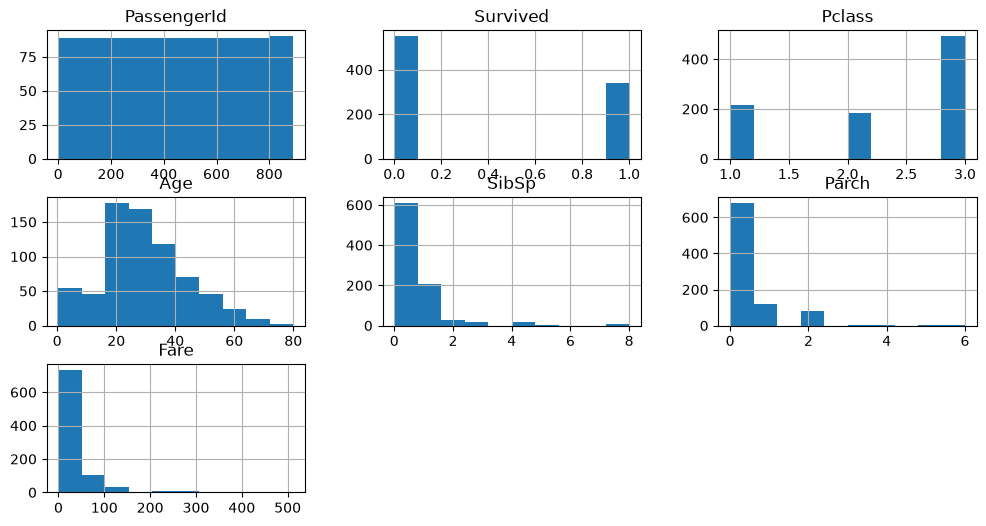

In [50]:
df.hist(figsize=(12,6))
plt.show()

* Survived: More passengers did not survive than survived.
* Pclass: Most passengers belonged to 3rd class, while 2nd class had the fewest passengers.
* Sex: The dataset contains more male passengers than female passengers.
* Age: Most passengers were between 20 and 40 years of age.
* SibSp: Most passengers were traveling without siblings or spouses.
* Parch: Most passengers were traveling without parents or children.
* Fare: Most passengers paid lower fares, with only a few paying very high fares.
* Embarked: Most passengers boarded from Southampton (2), followed by Cherbourg (0) and Queenstown (1).

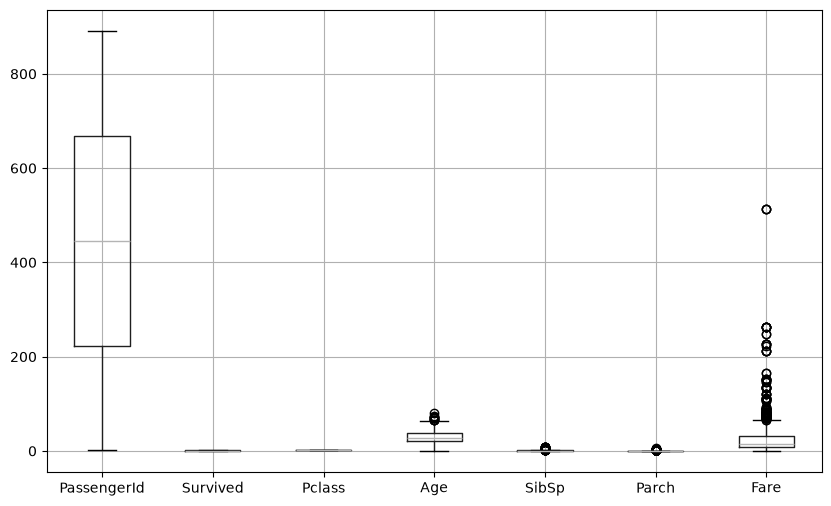

In [51]:
plt.figure(figsize=(10,6))
df.boxplot()
plt.show()

* Survived: No significant outliers are present since it is a binary variable.
* Pclass: No outliers are observed because it has only three class values.
* Sex: No outliers are present as it is an encoded categorical variable.
* Age: A few older passengers appear as outliers above the upper whisker.
* SibSp: Most passengers had few or no siblings/spouses, with a few high-value outliers.
* Parch: Most passengers had no parents/children aboard, with a few outliers having larger family sizes.
* Fare: Fare contains many high-value outliers, indicating a few passengers paid significantly higher fares.
* Embarked: No outliers are present since it is an encoded categorical variable.

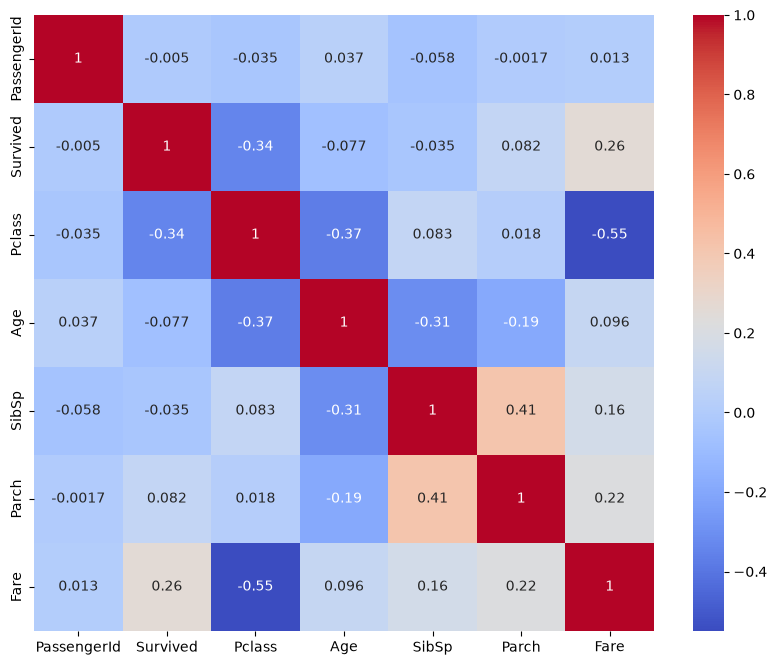

In [52]:
plt.figure(figsize=(10,8))
sns.heatmap(df.select_dtypes(include=np.number).corr(),annot=True,cmap="coolwarm")
plt.show()

* PassengerId: PassengerId has almost no correlation with any other feature.
* Survived: Survival has a moderate negative correlation with Pclass (-0.34) and a weak positive correlation with Fare (0.26).
* Pclass: Pclass has a moderate negative correlation with Fare (-0.55) and Age (-0.37).
* Age: Age has a weak negative correlation with SibSp (-0.31), while its correlation with other features is very low.
* SibSp: SibSp shows a moderate positive correlation with Parch (0.41), indicating family members often traveled together.
* Parch: Parch has a weak positive correlation with Fare (0.22) and Survived (0.08).
* Fare: Fare is moderately negatively correlated with Pclass (-0.55) and weakly positively correlated with Survived (0.26).

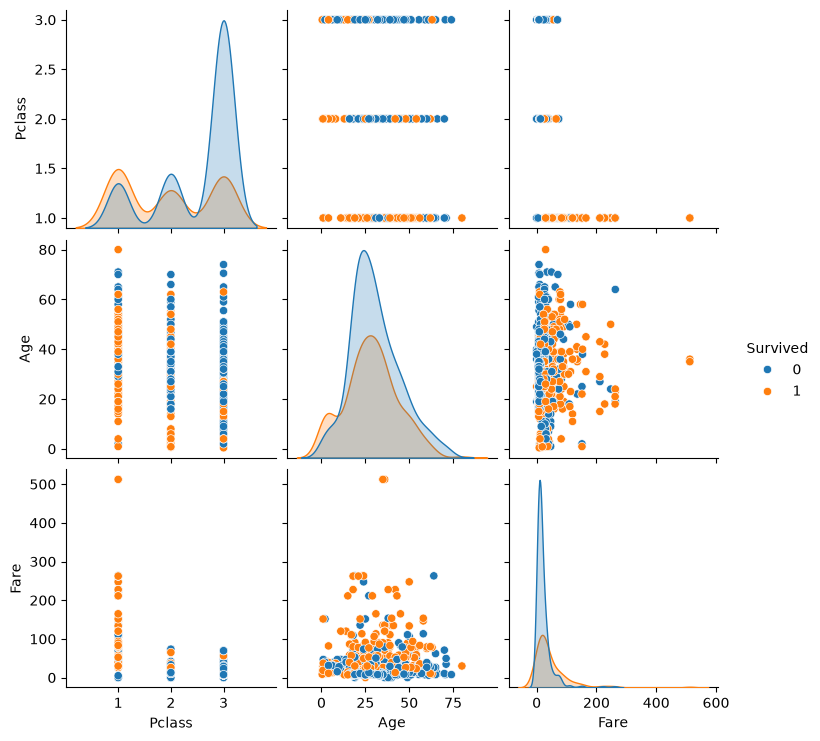

In [53]:
sns.pairplot(df[["Pclass","Age","Fare","Survived"]],hue="Survived")
plt.show()

* Pclass vs Survived: Passengers in 1st class had a higher survival rate than those in 2nd and 3rd class.
* Age vs Survived: Survivors and non-survivors are spread across all age groups, showing no clear separation based on age alone.
* Fare vs Survived: Passengers who paid higher fares were more likely to survive than those who paid lower fares.
* Pclass vs Fare: Higher fares are mostly associated with 1st class, while 3rd class passengers generally paid lower fares.
* Age vs Fare: There is no strong relationship between passenger age and fare paid.
* Overall: The classes overlap considerably, indicating that a single feature is not sufficient to distinguish survivors from non-survivors.

In [54]:
#Handling Missing Values
df["Age"]=df["Age"].fillna(df["Age"].median()) 
df["Embarked"]=df["Embarked"].fillna(df["Embarked"].mode()[0])

df=df.drop(columns=["Cabin","Name","Ticket","PassengerId"])

le=LabelEncoder()
df["Sex"]=le.fit_transform(df["Sex"]) #Encodind because only two possible values
#Getting dummies for Embarked column because it has more than two possible values
df = pd.get_dummies(df, columns=["Embarked"], drop_first=True, dtype=int)

X=df.drop("Survived",axis=1)
y=df["Survived"]

In [55]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

model=LogisticRegression(max_iter=1000)
model.fit(X_train,y_train)

y_pred=model.predict(X_test)
y_prob=model.predict_proba(X_test)[:,1] #because we need the probability of the positive class (1)

Accuracy: 0.8100558659217877
Precision: 0.7857142857142857
Recall: 0.7432432432432432
F1 Score: 0.7638888888888888
ROC AUC: 0.8824967824967825
              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179

[[90 15]
 [19 55]]


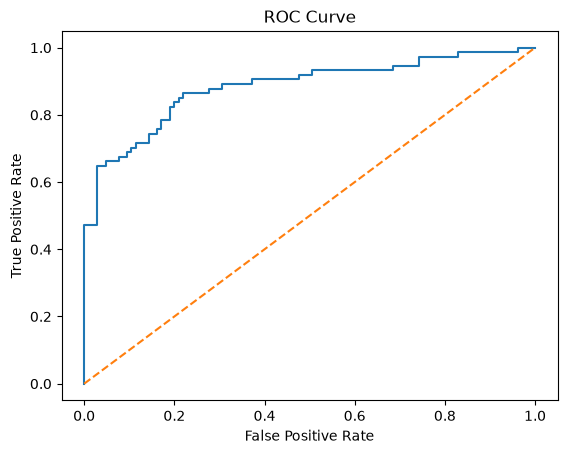

In [56]:
print("Accuracy:",accuracy_score(y_test,y_pred))
print("Precision:",precision_score(y_test,y_pred))
print("Recall:",recall_score(y_test,y_pred))
print("F1 Score:",f1_score(y_test,y_pred))
print("ROC AUC:",roc_auc_score(y_test,y_prob))

print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

fpr,tpr,_=roc_curve(y_test,y_prob)
plt.plot(fpr,tpr)
plt.plot([0,1],[0,1],"--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

The ROC curve is well above the diagonal line, showing that the Logistic Regression model can distinguish between survivors and non-survivors effectively. The ROC-AUC score of 0.88 indicates very good classification performance.

In [57]:
coef=pd.DataFrame({
    "Feature":X.columns,
    "Coefficient":model.coef_[0]
})
coef.sort_values("Coefficient",ascending=False)

,Feature,Coefficient
5,Fare,0.002573
2,Age,-0.030582
4,Parch,-0.108160
6,Embarked_Q,-0.112445
3,SibSp,-0.294932
7,Embarked_S,-0.400585
0,Pclass,-0.938450
1,Sex,-2.591121


In [58]:
#Now making predictions on the test dataset(no metric available since it doesnt have survived column)

#Loading the Titanic test dataset
test_df = pd.read_csv("Titanic_test.csv")

In [59]:
#Filling missing values
test_df["Age"] = test_df["Age"].fillna(test_df["Age"].median())
test_df["Fare"] = test_df["Fare"].fillna(test_df["Fare"].median())
test_df["Embarked"] = test_df["Embarked"].fillna(test_df["Embarked"].mode()[0])

#Removing unnecessary columns
test_df = test_df.drop(columns=["PassengerId","Name","Ticket","Cabin"])

#Encoding Sex column
test_df["Sex"] = le.transform(test_df["Sex"])

#Converting Embarked into dummy variables
test_df = pd.get_dummies(test_df, columns=["Embarked"], drop_first=True, dtype=int)

In [60]:
#Predicting survival
test_predictions = model.predict(test_df)

#Predicting survival probabilities
test_probabilities = model.predict_proba(test_df)[:,1]

In [61]:
print("Predicted Survival:")
print(test_predictions[:10])

print("\nPredicted Survival Probability:")
print(test_probabilities[:10])

Predicted Survival:
[0 0 0 0 1 0 1 0 1 0]

Predicted Survival Probability:
[0.1174     0.40283864 0.12841225 0.11165836 0.56865291 0.15777292
 0.67060939 0.18913573 0.76662444 0.08014146]


In [ ]:
#Creating PKL file for the trained model

import pickle

#Saving the trained Logistic Regression model
with open("logistic_model.pkl", "wb") as file:
    pickle.dump(model, file)

print("Model saved successfully.")

Model saved successfully.
